# fail2ban simulation

How many of the 345k failed SSH logins would `fail2ban` have stopped, and at what cost to legitimate users?

**fail2ban** watches failures per IP. When an IP reaches `maxretry` failures within `findtime`, it is banned for `bantime` and the firewall drops its connections. Defaults for the sshd jail: **5 failures in 10 minutes, 10-minute ban**.

**Replay rules** (`src/simulation.py`):
- An attempt from a banned IP is **blocked**. It does not count as a failure, because it never reaches sshd.
- The failure that triggers a ban is not blocked: fail2ban acts after seeing it.
- A successful login from a banned IP is a **locked-out user**, the cost of the policy.
- `bantime.increment`: each new ban of the same IP doubles the ban time.

**Simplifications:** one failure per attempt, and attackers keep the same behavior when banned (in reality many would move on, so real numbers could be even better).

In [1]:
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.charts import AQUA, BLUE, GRAY, INK_2, ORANGE, apply_style, mask_ip, subtitle, thousands
from src.simulation import DEFAULT_POLICY, Policy, load_events, policy_grid, simulate

apply_style()
FIGURES = ROOT / "reports" / "figures"

events = load_events(ROOT / "data" / "processed" / "ssh.db")
print(f"{len(events):,} events from {events[0][0]} to {events[-1][0]}")

345,245 events from 2017-12-10 06:55:48 to 2018-01-07 17:22:01


## 1. Comparing policies

In [2]:
results = [simulate(events, p) for p in policy_grid()]
table = pd.DataFrame([r.as_row() for r in results]).sort_values("reached_sshd")
table[["policy", "blocked_share", "reached_sshd", "banned_ips", "locked_out"]].reset_index(drop=True)

,policy,blocked_share,reached_sshd,banned_ips,locked_out
0,3 in 1h -> ban 1d,0.9851,5129,716,3
1,3 in 10m -> ban 1d,0.9833,5746,705,3
2,3 in 10m -> ban 10m (x2 per repeat),0.9811,6522,705,1
3,3 in 1h -> ban 1h,0.9788,7307,716,1
4,3 in 10m -> ban 1h,0.9780,7576,705,1
5,5 in 1h -> ban 1d,0.9771,7903,673,3
6,5 in 10m -> ban 1d,0.9768,7998,665,3
7,5 in 10m -> ban 10m (x2 per repeat),0.9734,9194,665,1
8,5 in 1h -> ban 1h,0.9692,10641,673,1
9,5 in 10m -> ban 1h,0.9689,10716,665,1


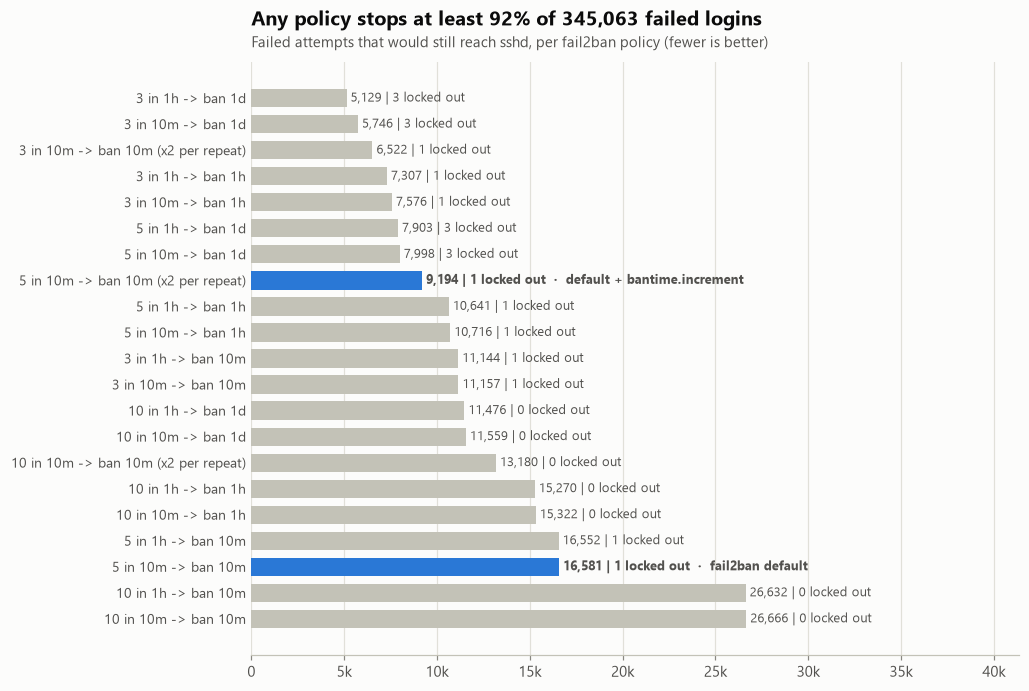

In [3]:
RECOMMENDED = Policy(increment=True)  # defaults + bantime.increment

fig, ax = plt.subplots(figsize=(9, 7))
plot = table.iloc[::-1]
colors = [BLUE if p in (DEFAULT_POLICY.name, RECOMMENDED.name) else GRAY for p in plot["policy"]]
ax.barh(plot["policy"], plot["reached_sshd"], height=0.7, color=colors)
for y, (name, reached, locked) in enumerate(zip(plot["policy"], plot["reached_sshd"], plot["locked_out"])):
    note = {DEFAULT_POLICY.name: "  ·  fail2ban default", RECOMMENDED.name: "  ·  default + bantime.increment"}.get(
        name, ""
    )
    ax.text(
        reached,
        y,
        f" {reached:,} | {locked} locked out{note}",
        va="center",
        color=INK_2,
        fontsize=8.5,
        fontweight="bold" if note else "normal",
    )
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.xaxis.set_major_formatter(thousands)
ax.set_xlim(0, table["reached_sshd"].max() * 1.55)
ax.tick_params(axis="y", length=0, labelsize=9)
ax.set_title(
    f"Any policy stops at least {table['blocked_share'].min():.0%} of {table['failed'].iloc[0]:,} failed logins"
)
subtitle(ax, "Failed attempts that would still reach sshd, per fail2ban policy (fewer is better)")
fig.savefig(FIGURES / "fail2ban_policies.png")
plt.show()

Reading the chart:
- **The default alone cuts attempts reaching sshd ~20x.**
- **`bantime.increment` is the best trade-off:** fewer attempts get through than with the default, with the same single locked-out login, close to a 1-day ban that locks out 3 logins.
- **Diminishing returns:** going from the incremental policy to the strictest one gains about one percentage point and triples the locked-out logins.
- `maxretry = 10` never locks anyone out here, but lets the most through.

## 2. Day by day

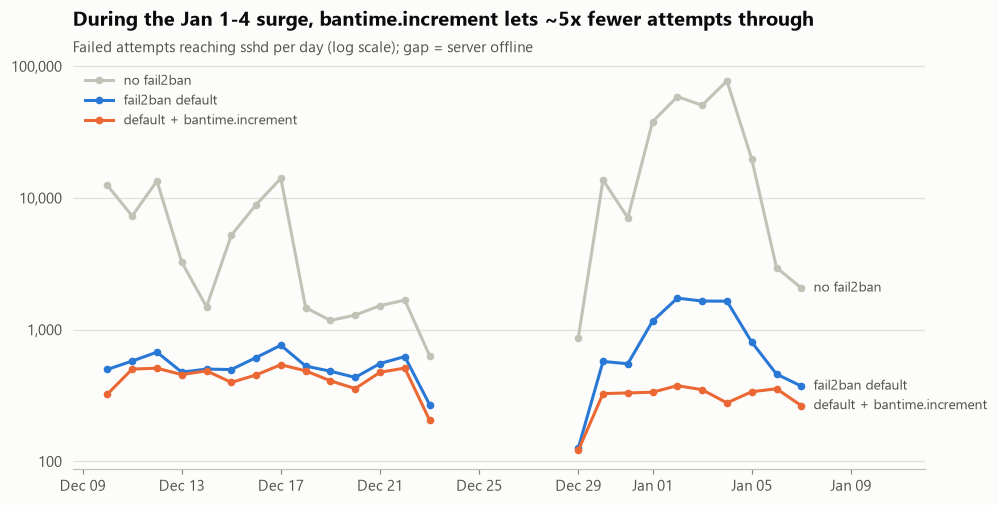

            no fail2ban  fail2ban default  default + bantime.increment
timestamp                                                             
2018-01-01        37965              1162                          335
2018-01-02        58762              1736                          376
2018-01-03        50559              1650                          350
2018-01-04        77420              1645                          278


In [4]:
df = pd.DataFrame(events, columns=["timestamp", "ip", "success"])
df["blocked_default"] = simulate(events, DEFAULT_POLICY, record=True).decisions
df["blocked_recommended"] = simulate(events, RECOMMENDED, record=True).decisions
failed = df[~df["success"]].set_index("timestamp")

daily = pd.DataFrame(
    {
        "no fail2ban": failed.resample("D").size(),
        "fail2ban default": (~failed["blocked_default"]).resample("D").sum(),
        "default + bantime.increment": (~failed["blocked_recommended"]).resample("D").sum(),
    }
)
offline = (daily.index > "2017-12-23") & (daily.index < "2017-12-29")
daily.loc[offline] = float("nan")  # server unreachable: break the lines instead of drawing zeros

fig, ax = plt.subplots(figsize=(10, 4.8))
for (name, series), color in zip(daily.items(), [GRAY, BLUE, ORANGE]):
    ax.plot(series.index, series.values, color=color, linewidth=2, marker="o", markersize=4, label=name)
    last = series.dropna()
    ax.annotate(
        name,
        xy=(last.index[-1], last.iloc[-1]),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
        color=INK_2,
        fontsize=9,
    )
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_xlim(right=daily.index[-1] + pd.Timedelta(days=5))
ax.legend(loc="upper left", fontsize=9)
ax.set_title("During the Jan 1-4 surge, bantime.increment lets ~5x fewer attempts through")
subtitle(ax, "Failed attempts reaching sshd per day (log scale); gap = server offline")
fig.savefig(FIGURES / "fail2ban_daily.png")
plt.show()

print(daily.loc["2018-01-01":"2018-01-04"].astype(int))

## 3. What still gets through?

Under the default policy, attempts that still reach sshd come from two kinds of IPs:
- **banned at some point**: the failures that trigger each ban, and the bot coming back after every 10-minute ban;
- **never banned**: IPs that stay below 5 failures in 10 minutes, the "low and slow" attackers fail2ban cannot see.

In [5]:
f = df[~df["success"]]
reached = f[~f["blocked_default"]]
banned_ips = simulate(events, DEFAULT_POLICY).banned_ips
kind = reached["ip"].isin(banned_ips).map({True: "banned at some point", False: "never banned"})
summary = pd.DataFrame(
    {
        "attempts reaching sshd": kind.value_counts(),
        "IPs": reached.groupby(kind)["ip"].nunique(),
    }
)
summary["share of attempts"] = (summary["attempts reaching sshd"] / summary["attempts reaching sshd"].sum()).round(3)
summary

,attempts reaching sshd,IPs,share of attempts
ip,,,
banned at some point,13891,665,0.838
never banned,2690,345,0.162


In [6]:
never = f[~f["ip"].isin(banned_ips)]
per_ip = never.groupby("ip").agg(attempts=("ip", "size"), first=("timestamp", "min"), last=("timestamp", "max"))
print(
    f"{len(per_ip)} IPs never banned | median {per_ip['attempts'].median():.0f} attempts each | "
    f"{(per_ip['attempts'] == 1).mean():.0%} tried only once"
)
print(
    f"Most persistent never-banned IP: {per_ip['attempts'].max()} attempts over "
    f"{(per_ip.loc[per_ip['attempts'].idxmax(), 'last'] - per_ip.loc[per_ip['attempts'].idxmax(), 'first']).days} days"
)

345 IPs never banned | median 1 attempts each | 52% tried only once
Most persistent never-banned IP: 569 attempts over 12 days


## 4. Who gets locked out?

Logins blocked under each highlighted policy. IPs are masked and usernames are not shown (real lab users).

In [7]:
for name, col in [("fail2ban default", "blocked_default"), ("default + bantime.increment", "blocked_recommended")]:
    locked = df[df["success"] & df[col]]
    print(f"{name}: {len(locked)} login(s) blocked")
    for ts, ip in zip(locked["timestamp"], locked["ip"]):
        history = df[(df["ip"] == ip) & (df["timestamp"] <= ts)]
        recent_fails = history[~history["success"] & (history["timestamp"] > ts - pd.Timedelta(minutes=30))]
        print(f"  {ts}  {mask_ip(ip)}  {len(recent_fails)} failed attempts in the 30 min before")

fail2ban default: 1 login(s) blocked
  2017-12-20 17:26:55  123.255.103.x  5 failed attempts in the 30 min before
default + bantime.increment: 1 login(s) blocked
  2017-12-20 17:26:55  123.255.103.x  5 failed attempts in the 30 min before


## Takeaways

1. **The fail2ban default blocks 95% of failed logins** in this log: attempts reaching sshd drop from 345k to ~16.6k, and 665 of 1,010 attacking IPs get banned at least once.
2. **Turn on `bantime.increment`.** It lets ~45% fewer attempts through than the default (5x fewer during the Jan 1-4 surge), with no extra locked-out users, because the heaviest bots keep coming back and each ban gets longer.
3. **Stricter is not much better.** The strictest policy tested gains about one percentage point and triples the locked-out logins.
4. **What gets through is mostly bots coming back.** Under the default policy, 84% of the attempts that still reach sshd come from IPs that were banned and returned after each 10-minute ban, which is exactly what `bantime.increment` fixes. Only 16% come from "low and slow" IPs that never cross the threshold (half of them tried once; the most persistent made 569 attempts over 12 days).
5. **The only locked-out login** is a user who failed 5 times in 30 minutes before getting the password right. Any rule strict enough to stop bots will occasionally catch a human; key-based login removes the problem.

Suggested `/etc/fail2ban/jail.local` for this server:

```ini
[sshd]
enabled = true
maxretry = 5
findtime = 10m
bantime = 10m
bantime.increment = true
```

And in `/etc/ssh/sshd_config`, which makes the remaining password guesses useless:

```
PermitRootLogin no
PasswordAuthentication no
```